In [42]:
import pandas as pd

In [43]:
df= pd.read_excel("HousePricePrediction.xlsx")

In [44]:
df.head(5)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [45]:
df.shape

(2919, 13)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [47]:
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64


In [48]:
cat_col=df.select_dtypes(include='object').columns
int_col=df.select_dtypes(include='int64').columns
float_col=df.select_dtypes(include='float64').columns

print("Categorical Columns: ",len(cat_col))
print("Interal Columns: ",len(int_col))
print("Float Columns: ",len(float_col))

Categorical Columns:  4
Interal Columns:  6
Float Columns:  3


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

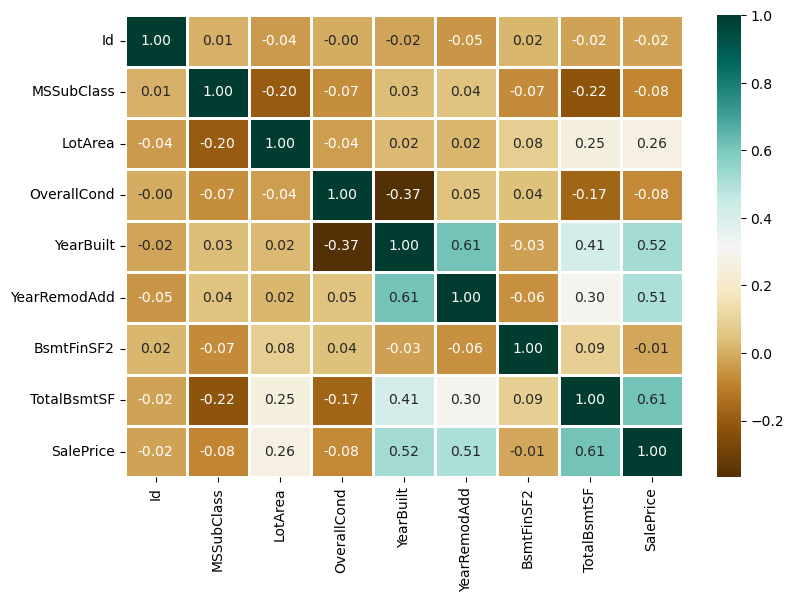

In [50]:
numeric_features= df.select_dtypes(include=['number'])

plt.figure(figsize=(9,6))
sns.heatmap(numeric_features.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidth=2,
            annot=True
           )
plt.show()             
                                   

<Axes: title={'center': 'No. Unique Values of Categorical Features'}, xlabel='None'>

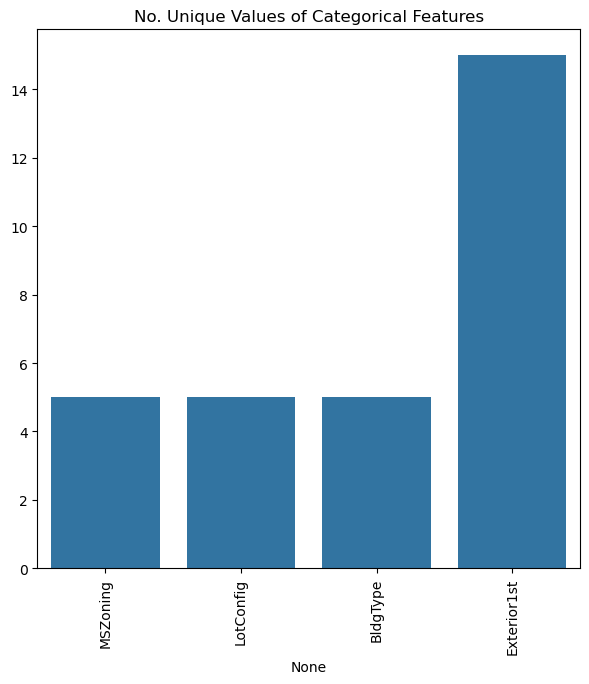

In [51]:
unique_counts= df[cat_col].nunique()

plt.figure(figsize=(7,7))
plt.title('No. Unique Values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=unique_counts.index, y=unique_counts.values)


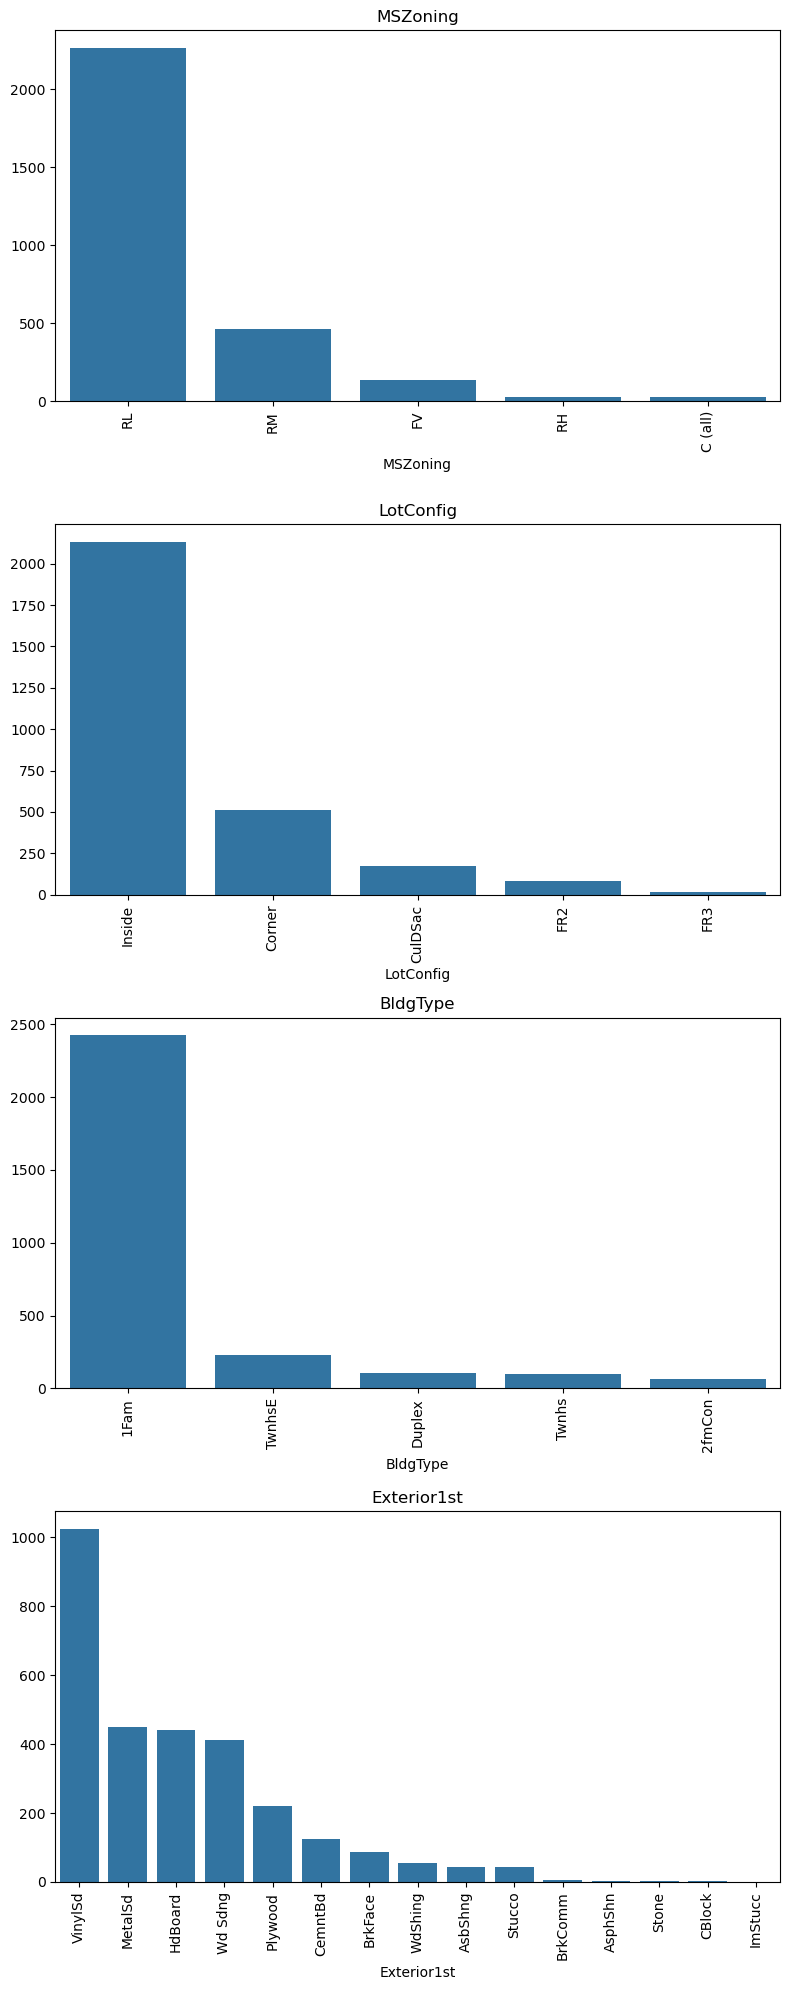

In [52]:
fig, axes = plt.subplots(len(cat_col), 1, figsize=(8, 5 * len(cat_col)))

for ax, col in zip(axes, cat_col):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [54]:
df.drop('Id',axis=1,inplace=True)

In [55]:
df['SalePrice']=df['SalePrice'].fillna(df['SalePrice'].mean())

In [57]:
df.isnull().sum()

MSSubClass      0
MSZoning        4
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     1
BsmtFinSF2      1
TotalBsmtSF     1
SalePrice       0
dtype: int64

In [61]:
df = df.dropna()

In [62]:
df.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [63]:
print("Number of categorical column: ",len(cat_col))
print("Name of Categorical column are: ",list(cat_col))

Number of categorical column:  4
Name of Categorical column are:  ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']


In [64]:
from sklearn.preprocessing import OneHotEncoder

OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

OH_cols = pd.DataFrame(
    OH_encoder.fit_transform(df[cat_col]),
    columns=OH_encoder.get_feature_names_out(),
    index=df.index
)

# Combine with original dataset
df_final = pd.concat([df.drop(columns=cat_col), OH_cols], axis=1)


In [65]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0)

In [67]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model = svm.SVR()
model.fit(X_train,Y_train)
Y_pred = model .predict(X_test)

print(mean_absolute_percentage_error(Y_test, Y_pred))

0.1870512931870423


In [69]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_test)

mean_absolute_percentage_error(Y_test, Y_pred)

0.19261360927925048

In [70]:
from xgboost import XGBRegressor

In [71]:
model_XGB = XGBRegressor(n_estimators=10)
model_XGB.fit(X_train, Y_train)
Y_pred = model_XGB.predict(X_test)

mean_absolute_percentage_error(Y_test, Y_pred)

0.18411819576786492